In [3]:
!pip install xgboost


# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [1]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

#Hint: install xgboost in Colab if missing
#!pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

Aperçu du dataset :


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1



Dimensions du dataset :
(270, 14)

Colonnes du dataset :
['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal', 'heart disease']

Types des colonnes :
age                                       int64
sex                                       int64
chest pain type                           int64
resting blood pressure                    int64
serum cholestoral                         int64
fasting blood sugar                       int64
resting electrocardiographic results      int64
max heart rate                            int64
exercise induced angina                   int64
oldpeak                                 float64
ST segment                                int64
major vessels                             int64
thal                                      int64
heart disease                          

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000



Nombre de doublons :
0

Dimensions après suppression des doublons :
(270, 14)

Colonne cible utilisée : heart disease

Répartition de la variable cible avant transformation :
heart disease
1    150
2    120
Name: count, dtype: int64

Répartition de la variable cible après transformation :
heart disease
0    150
1    120
Name: count, dtype: int64


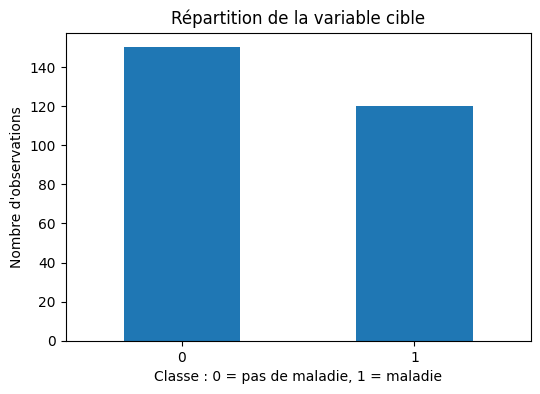


Variables explicatives X :
['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal']

Variable cible y :
heart disease

Taille de X_train : (216, 13)
Taille de X_test : (54, 13)
Taille de y_train : (216,)
Taille de y_test : (54,)


In [3]:


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

csv_path = "/content/dataset_heart.csv"
df = pd.read_csv(csv_path)

print("Aperçu du dataset :")
display(df.head())

print("\nDimensions du dataset :")
print(df.shape)

print("\nColonnes du dataset :")
print(df.columns.tolist())

print("\nTypes des colonnes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isnull().sum())

print("\nStatistiques descriptives :")
display(df.describe())

print("\nNombre de doublons :")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nDimensions après suppression des doublons :")
print(df.shape)

target = "heart disease"

print("\nColonne cible utilisée :", target)

print("\nRépartition de la variable cible avant transformation :")
print(df[target].value_counts())


df[target] = df[target].map({
    1: 0,
    2: 1
})

print("\nRépartition de la variable cible après transformation :")
print(df[target].value_counts())

plt.figure(figsize=(6, 4))
df[target].value_counts().plot(kind="bar")
plt.title("Répartition de la variable cible")
plt.xlabel("Classe : 0 = pas de maladie, 1 = maladie")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()

X = df.drop(columns=[target])
y = df[target]

print("\nVariables explicatives X :")
print(X.columns.tolist())

print("\nVariable cible y :")
print(target)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTaille de X_train :", X_train.shape)
print("Taille de X_test :", X_test.shape)
print("Taille de y_train :", y_train.shape)
print("Taille de y_test :", y_test.shape)


### Basic visual checks

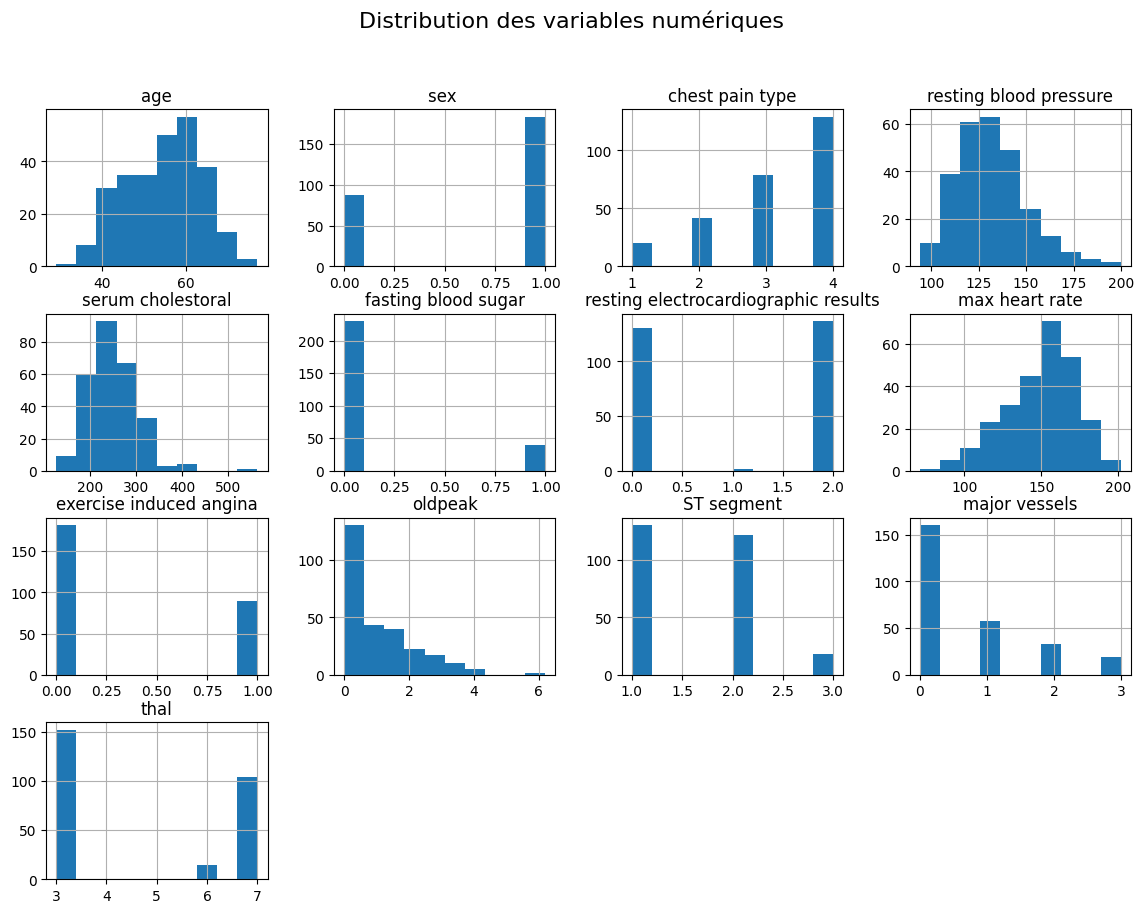

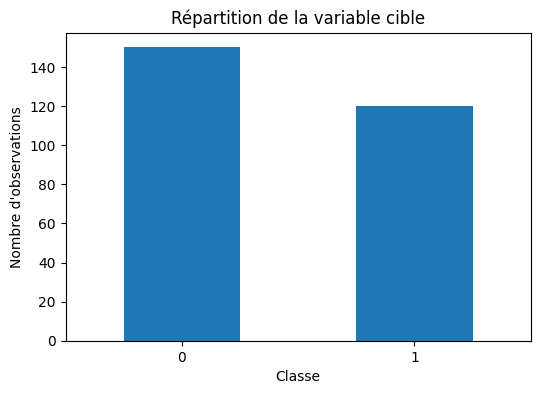

In [4]:

numeric_cols_for_plot = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

df[numeric_cols_for_plot].hist(figsize=(14, 10))
plt.suptitle("Distribution des variables numériques", fontsize=16)
plt.show()

plt.figure(figsize=(6, 4))
df[target].value_counts().plot(kind="bar")
plt.title("Répartition de la variable cible")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()

## Preprocessing pipeline

In [5]:

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Colonnes catégorielles :", cat_cols)
print("Colonnes numériques :", num_cols)

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


Colonnes catégorielles : []
Colonnes numériques : ['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal']


## Helper - evaluation function

In [7]:


def eval_and_report(name, model, X_test, y_test):
    """
    Cette fonction évalue un modèle avec plusieurs métriques.
    Elle affiche aussi la matrice de confusion et la courbe ROC si possible.
    """

    y_pred = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    print("\n===============")
    print(name)
    print("=================")

    print("Accuracy :", round(metrics["accuracy"], 4))
    print("Precision :", round(metrics["precision"], 4))
    print("Recall :", round(metrics["recall"], 4))
    print("F1-score :", round(metrics["f1"], 4))

    cm = confusion_matrix(y_test, y_pred)

    print("\nMatrice de confusion :")
    print(cm)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Matrice de confusion - {name}")
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_proba)
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)

        print("ROC-AUC :", round(auc, 4))

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", label="Modèle aléatoire")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Courbe ROC - {name}")
        plt.legend()
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search


Logistic Regression sans GridSearchCV
Accuracy : 0.8519
Precision : 0.7857
Recall : 0.9167
F1-score : 0.8462

Matrice de confusion :
[[24  6]
 [ 2 22]]


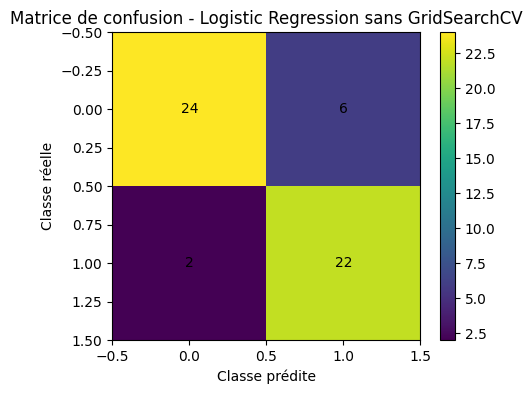

ROC-AUC : 0.8986


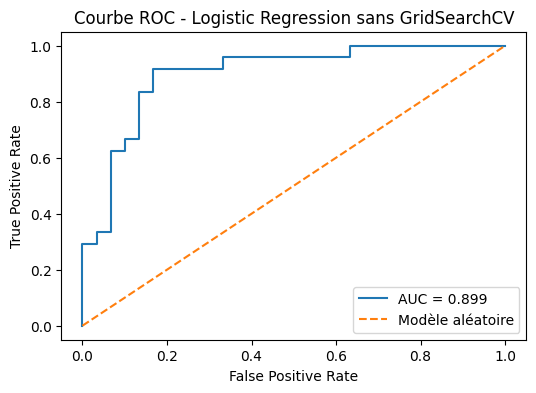

In [8]:


pipe_lr = Pipeline(
    steps=[
        ("pre", pre),
        ("lr", LogisticRegression(
            solver="liblinear",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]
)

pipe_lr.fit(X_train, y_train)

lr_no_gs_metrics = eval_and_report(
    "Logistic Regression sans GridSearchCV",
    pipe_lr,
    X_test,
    y_test
)


## Exercise 3 - Logistic Regression with Grid Search

Meilleurs paramètres Logistic Regression :
{'lr__C': 0.1, 'lr__penalty': 'l2'}
Meilleur score de validation croisée :
0.8146

Logistic Regression avec GridSearchCV
Accuracy : 0.8519
Precision : 0.7857
Recall : 0.9167
F1-score : 0.8462

Matrice de confusion :
[[24  6]
 [ 2 22]]


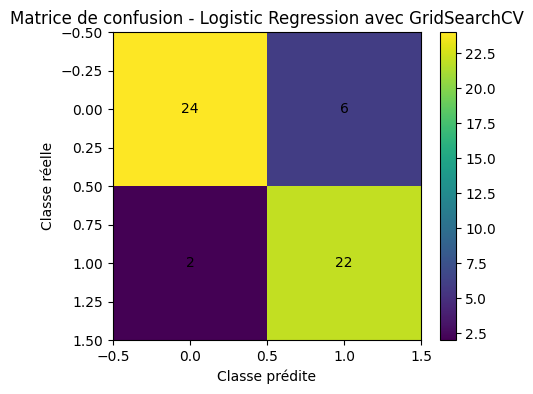

ROC-AUC : 0.9083


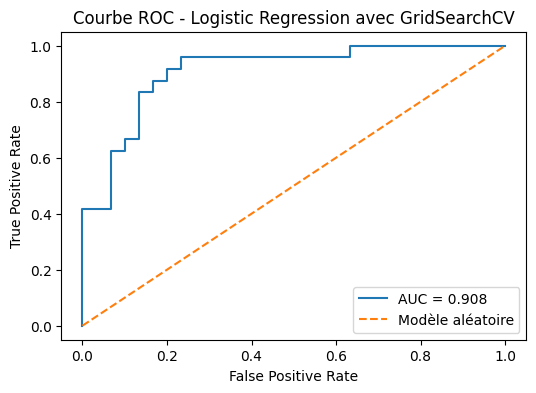

In [9]:


pipe_lr_cv = Pipeline(
    steps=[
        ("pre", pre),
        ("lr", LogisticRegression(
            solver="liblinear",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]
)

param_grid = {
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__penalty": ["l1", "l2"]
}

grid_lr = GridSearchCV(
    estimator=pipe_lr_cv,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Meilleurs paramètres Logistic Regression :")
print(grid_lr.best_params_)

print("Meilleur score de validation croisée :")
print(round(grid_lr.best_score_, 4))

best_lr = grid_lr.best_estimator_

lr_gs_metrics = eval_and_report(
    "Logistic Regression avec GridSearchCV",
    best_lr,
    X_test,
    y_test
)

## Exercise 4 - SVM without Grid Search


SVM sans GridSearchCV
Accuracy : 0.8148
Precision : 0.7692
Recall : 0.8333
F1-score : 0.8

Matrice de confusion :
[[24  6]
 [ 4 20]]


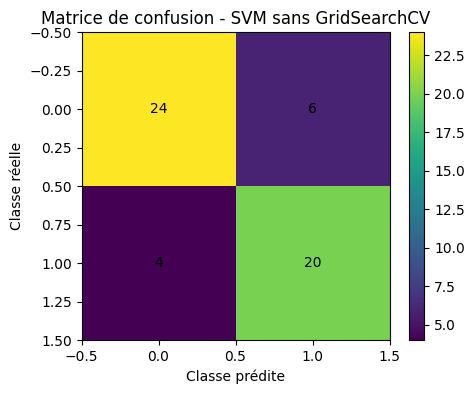

ROC-AUC : 0.8861


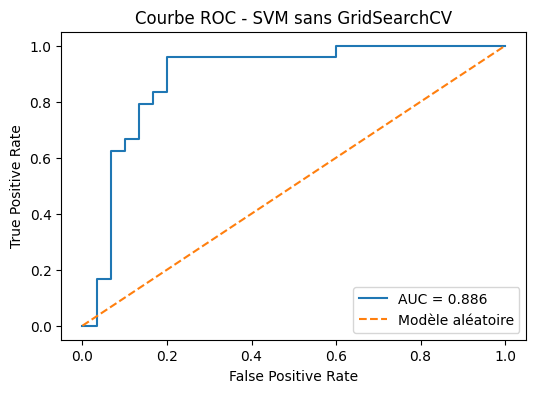

In [10]:


pipe_svm = Pipeline(
    steps=[
        ("pre", pre),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]
)

pipe_svm.fit(X_train, y_train)

svm_no_metrics = eval_and_report(
    "SVM sans GridSearchCV",
    pipe_svm,
    X_test,
    y_test
)

## Exercise 5 - SVM with Grid Search

Meilleurs paramètres SVM :
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Meilleur score de validation croisée :
0.8151

SVM avec GridSearchCV
Accuracy : 0.8519
Precision : 0.8077
Recall : 0.875
F1-score : 0.84

Matrice de confusion :
[[25  5]
 [ 3 21]]


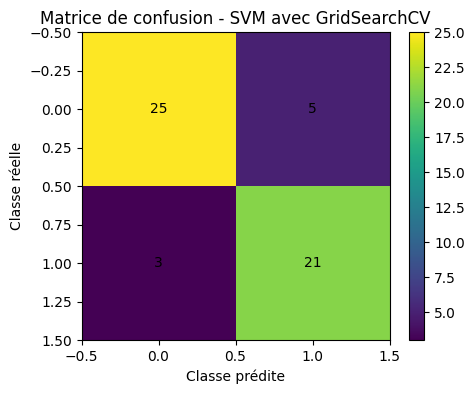

ROC-AUC : 0.9056


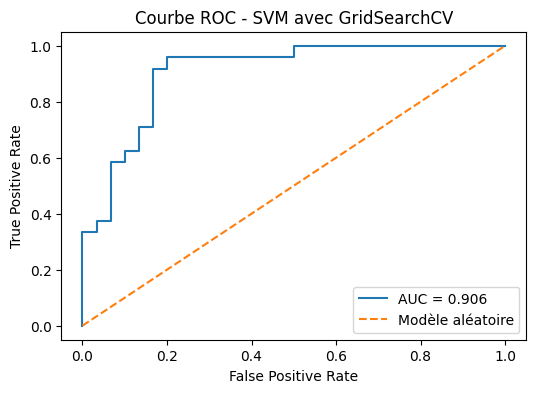

In [11]:


pipe_svm_cv = Pipeline(
    steps=[
        ("pre", pre),
        ("svm", SVC(
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]
)

svm_param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    estimator=pipe_svm_cv,
    param_grid=svm_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Meilleurs paramètres SVM :")
print(grid_svm.best_params_)

print("Meilleur score de validation croisée :")
print(round(grid_svm.best_score_, 4))

best_svm = grid_svm.best_estimator_

svm_gs_metrics = eval_and_report(
    "SVM avec GridSearchCV",
    best_svm,
    X_test,
    y_test
)

## Exercise 6 - XGBoost without Grid Search


XGBoost sans GridSearchCV
Accuracy : 0.7963
Precision : 0.7407
Recall : 0.8333
F1-score : 0.7843

Matrice de confusion :
[[23  7]
 [ 4 20]]


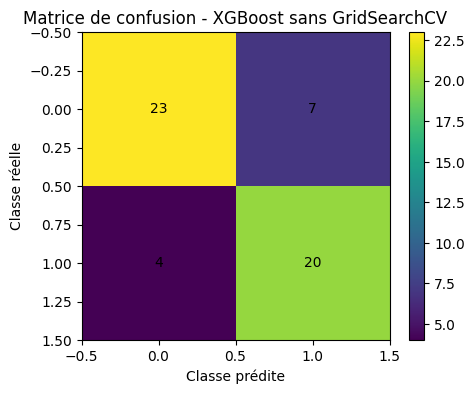

ROC-AUC : 0.8694


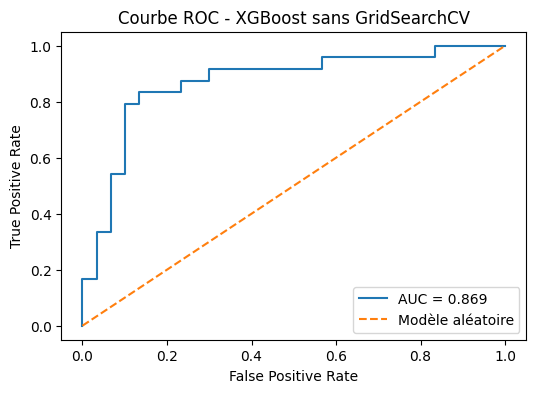

In [12]:


if XGBClassifier is None:
    print("XGBoost n'est pas installé. Exécute d'abord : !pip install xgboost")
else:
    pipe_xgb = Pipeline(
        steps=[
            ("pre", pre),
            ("xgb", XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                eval_metric="logloss",
                random_state=RANDOM_STATE
            ))
        ]
    )

    pipe_xgb.fit(X_train, y_train)

    xgb_no_metrics = eval_and_report(
        "XGBoost sans GridSearchCV",
        pipe_xgb,
        X_test,
        y_test
    )

## Exercise 7 - XGBoost with Grid Search

Meilleurs paramètres XGBoost :
{'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Meilleur score de validation croisée :
0.7939

XGBoost avec GridSearchCV
Accuracy : 0.7963
Precision : 0.7407
Recall : 0.8333
F1-score : 0.7843

Matrice de confusion :
[[23  7]
 [ 4 20]]


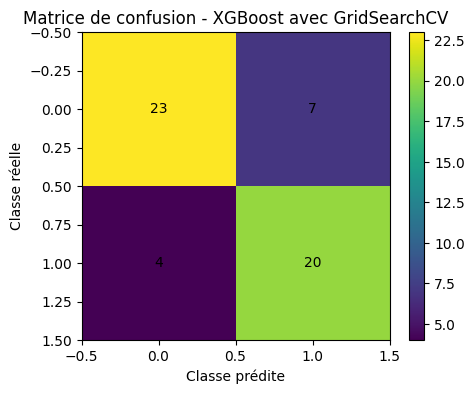

ROC-AUC : 0.8819


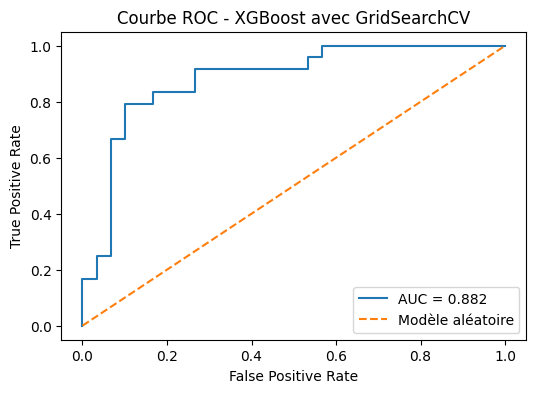

In [13]:


if XGBClassifier is None:
    print("XGBoost n'est pas installé. Exécute d'abord : !pip install xgboost")
else:
    pipe_xgb_cv = Pipeline(
        steps=[
            ("pre", pre),
            ("xgb", XGBClassifier(
                eval_metric="logloss",
                random_state=RANDOM_STATE
            ))
        ]
    )

    xgb_param_grid = {
        "xgb__n_estimators": [50, 100],
        "xgb__learning_rate": [0.01, 0.1],
        "xgb__max_depth": [3, 5],
        "xgb__subsample": [0.8, 1.0],
        "xgb__colsample_bytree": [0.8, 1.0]
    }

    grid_xgb = GridSearchCV(
        estimator=pipe_xgb_cv,
        param_grid=xgb_param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid_xgb.fit(X_train, y_train)

    print("Meilleurs paramètres XGBoost :")
    print(grid_xgb.best_params_)

    print("Meilleur score de validation croisée :")
    print(round(grid_xgb.best_score_, 4))

    best_xgb = grid_xgb.best_estimator_

    xgb_gs_metrics = eval_and_report(
        "XGBoost avec GridSearchCV",
        best_xgb,
        X_test,
        y_test
    )

## Compare models

,accuracy,precision,recall,f1
LR no grid,0.851852,0.785714,0.916667,0.846154
LR grid,0.851852,0.785714,0.916667,0.846154
SVM no grid,0.814815,0.769231,0.833333,0.800000
SVM grid,0.851852,0.807692,0.875000,0.840000
XGB no grid,0.796296,0.740741,0.833333,0.784314
XGB grid,0.796296,0.740741,0.833333,0.784314


,accuracy,precision,recall,f1
LR no grid,0.851852,0.785714,0.916667,0.846154
LR grid,0.851852,0.785714,0.916667,0.846154
SVM grid,0.851852,0.807692,0.875000,0.840000
SVM no grid,0.814815,0.769231,0.833333,0.800000
XGB no grid,0.796296,0.740741,0.833333,0.784314
XGB grid,0.796296,0.740741,0.833333,0.784314


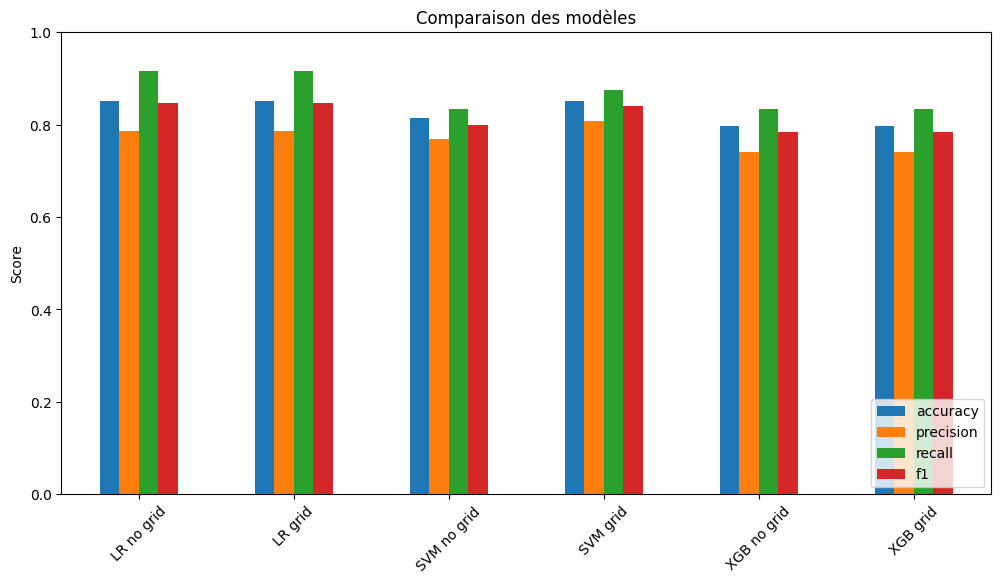

In [14]:

summary = {
    "LR no grid": lr_no_gs_metrics,
    "LR grid": lr_gs_metrics,
    "SVM no grid": svm_no_metrics,
    "SVM grid": svm_gs_metrics,
}

if "xgb_no_metrics" in globals():
    summary["XGB no grid"] = xgb_no_metrics

if "xgb_gs_metrics" in globals():
    summary["XGB grid"] = xgb_gs_metrics

summary_df = pd.DataFrame(summary).T

display(summary_df)

display(summary_df.sort_values(by="f1", ascending=False))

summary_df[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparaison des modèles")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()